In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
raw_df = pd.read_csv("..//data//raw_data.csv")

<h1>Description of data<h1>

<h3>Attributes' Description</h3>
<b>Administrative</b>: Number of administrative pages visited by the user <br>
<b>Administrative_Duration</b>: Length of time spent on administrative pages, measured in seconds <br>
<b>Informational</b>: Number of informational pages visited by the user <br>
<b>Informational_Duration</b>: Length of time spent on informational pages, measured in seconds <br>
<b>ProductRelated</b>: Number of product related pages visited by the user <br>
<b>ProductRelated_Duration</b>: Length of time spent on product related pages, measured in seconds <br>
<b>BounceRates</b>: Proportion of users who leave the site after only interacting with a single page <br>
<b>ExitRates</b>: Proportion of views to a particular page that were the last in a user’s session <br>
<b>PageValues</b>: Average number of pages visited by a user prior to a transaction taking place <br>
<b>SpecialDay</b>: Closeness of the visit to a notable day of the year (e.g., Christmas Day, Mother’s Day, Valentine’s Day) <br>
<b>Month</b>: Month in which the site visit took place <br>
<b>OperatingSystems</b>: Operating system of the  <br>
<b>Browser</b>: Browser of the user  <br>
<b>Region</b>: Geographical region of the user  <br>
<b>TrafficType</b>: Traffic type of the user  <br>
<b>VistorType</b>: Whether the user is new or returning  <br>
<b>Weekend</b>: Whether the site visit took place on a weekend  <br>
<b>Revenue</b>: Whether the site visit resulted in a transaction taking place  <br>

In [17]:
print(raw_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
y = raw_df['Revenue']
x = raw_df.drop('Revenue', axis=1)

In [20]:
## early splitting to prevent data leakage
df_train, df_test = train_test_split(raw_df, test_size=0.2, random_state=42)

In [21]:
df_train.to_csv('..//data//train_data.csv', index=False)
df_test.to_csv('..//data//test_data.csv', index=False)

In [23]:
df_train.shape

(9864, 18)

## Ater Splitting Data
Note: - Splitting Needs to be done only one time

In [26]:
df_train = pd.read_csv('..//data//train_data.csv')

In [27]:
df_train.sample(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
7096,0,0.0,0,0.0,5,334.400000,0.000000,0.025000,0.000000,0.0,Sep,3,2,6,1,Returning_Visitor,False,False
5510,0,0.0,0,0.0,24,1476.021429,0.013043,0.024379,0.000000,0.0,Sep,2,2,8,2,Returning_Visitor,False,False
7612,0,0.0,0,0.0,8,335.250000,0.100000,0.108333,0.000000,0.0,Nov,3,12,1,1,Returning_Visitor,False,True
7464,2,21.0,0,0.0,25,278.136667,0.000000,0.007692,77.457986,0.0,Nov,2,2,7,2,New_Visitor,False,False
9102,0,0.0,0,0.0,6,218.000000,0.000000,0.066667,0.000000,0.0,Mar,2,2,3,1,Returning_Visitor,False,False


using a small random sample for EDA

In [28]:
sample_df = df_train.sample(2000, random_state=42)   # using a subset of data for EDA

In [29]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 9746 to 9854
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           2000 non-null   int64  
 1   Administrative_Duration  2000 non-null   float64
 2   Informational            2000 non-null   int64  
 3   Informational_Duration   2000 non-null   float64
 4   ProductRelated           2000 non-null   int64  
 5   ProductRelated_Duration  2000 non-null   float64
 6   BounceRates              2000 non-null   float64
 7   ExitRates                2000 non-null   float64
 8   PageValues               2000 non-null   float64
 9   SpecialDay               2000 non-null   float64
 10  Month                    2000 non-null   object 
 11  OperatingSystems         2000 non-null   int64  
 12  Browser                  2000 non-null   int64  
 13  Region                   2000 non-null   int64  
 14  TrafficType              2

<Axes: ylabel='count'>

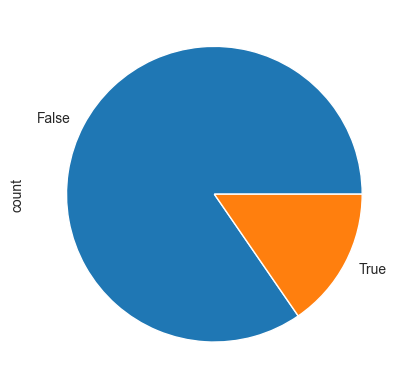

In [37]:
sample_df['Revenue'].value_counts().plot(kind = 'pie')

In [40]:
print(f"Proability of a random shopper completing its transaction is : {sample_df[sample_df['Revenue'] == True].shape[0]/sample_df.shape[0]*100}%")

Proability of a random shopper completing its transaction is : 15.4%


<Axes: >

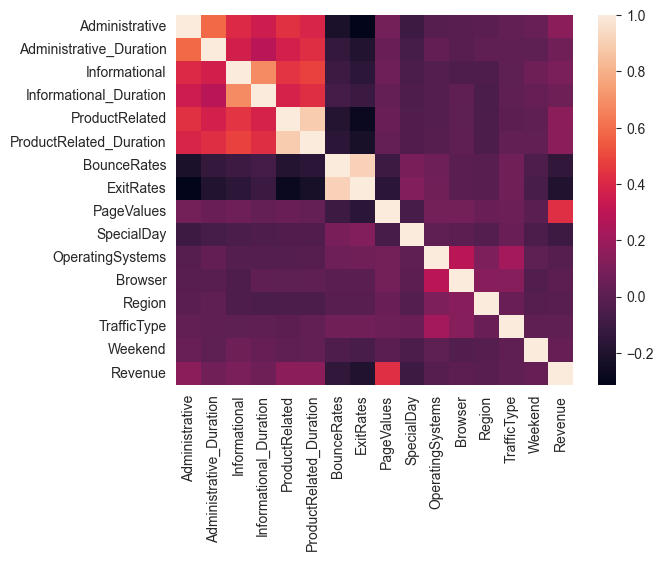

In [31]:
sns.heatmap(sample_df.drop(columns=['VisitorType', 'Month']).corr())

<Axes: xlabel='Administrative', ylabel='Administrative_Duration'>

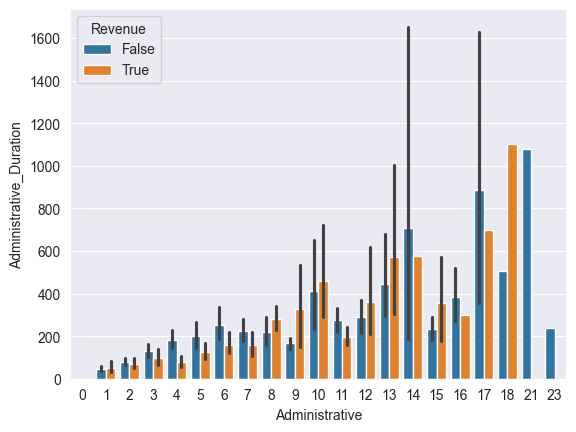

In [41]:
sns.barplot(data = sample_df, x = 'Administrative',y ='Administrative_Duration', hue = 'Revenue',)

<Axes: xlabel='Revenue', ylabel='Administrative'>

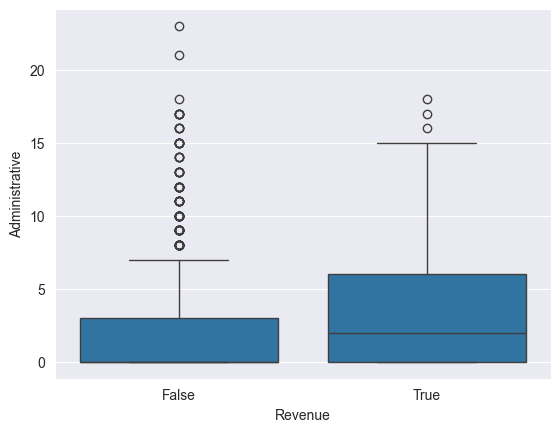

In [71]:
sns.boxplot(y = sample_df['Administrative'],x = sample_df['Revenue'])

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

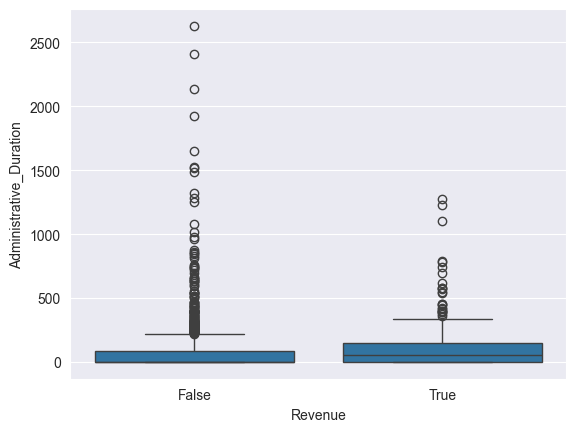

In [72]:
sns.boxplot(y = sample_df['Administrative_Duration'],x = sample_df['Revenue'])

<Axes: xlabel='Revenue', ylabel='Administrative'>

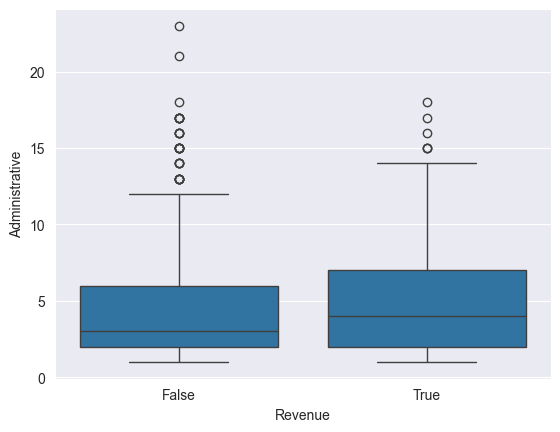

In [82]:
sns.boxplot(data = sample_df[sample_df['Administrative'] != 0] , y = 'Administrative', x = 'Revenue')

<Axes: ylabel='count'>

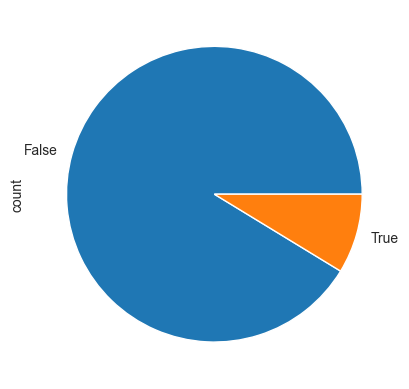

In [84]:
sample_df[sample_df['Administrative'] == 0]['Revenue'].value_counts().plot(kind = 'pie')

Clearly higher no of Administrative pages visit, increases chance of a successfull conversion, but not guarantees it

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

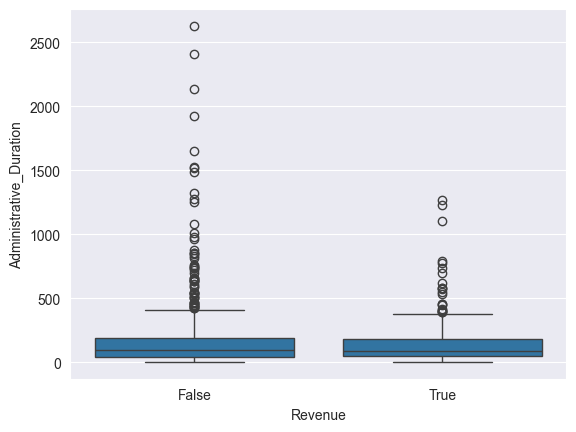

In [81]:
sns.boxplot(data = sample_df[sample_df['Administrative_Duration'] != 0] , y = 'Administrative_Duration', x = 'Revenue')

<Axes: xlabel='Administrative', ylabel='Informational'>

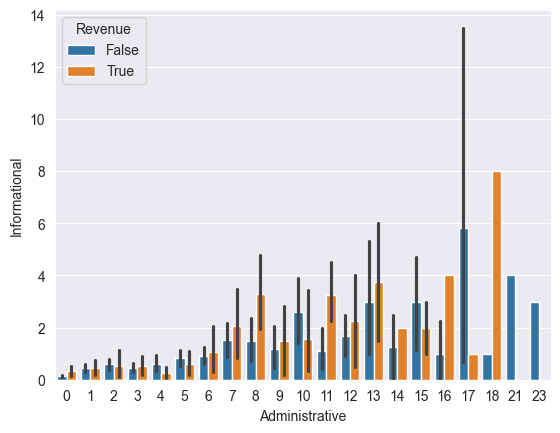

In [45]:
sns.barplot(data = sample_df, x = 'Administrative',y ='Informational', hue = 'Revenue')

So clearly visiting more informational pages leads to more transactions along with visiting administrative pages in most of cases.

<Axes: xlabel='Informational_Duration', ylabel='Informational'>

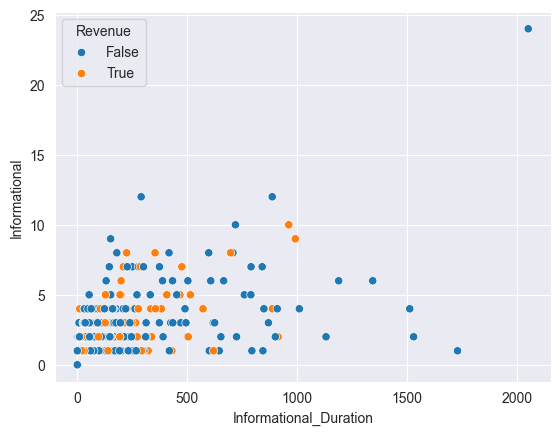

In [64]:
sns.scatterplot(data = sample_df, x = 'Informational_Duration',y ='Informational', hue = 'Revenue')

<Axes: xlabel='Informational_Duration', ylabel='Informational'>

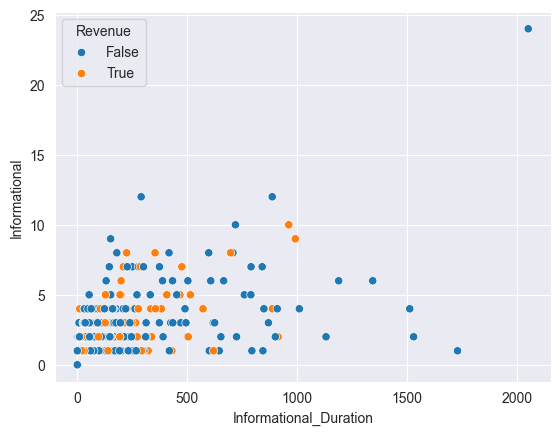

In [67]:
sns.scatterplot(data = sample_df, x = 'Informational_Duration',y ='Informational', hue = 'Revenue')

<Axes: xlabel='Revenue', ylabel='Informational'>

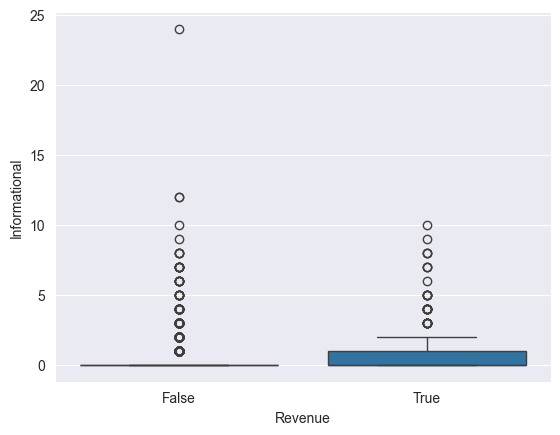

In [70]:
sns.boxplot(y = sample_df['Informational'],x = sample_df['Revenue'])

So there are clearly outliers in data

<Axes: xlabel='Revenue', ylabel='BounceRates'>

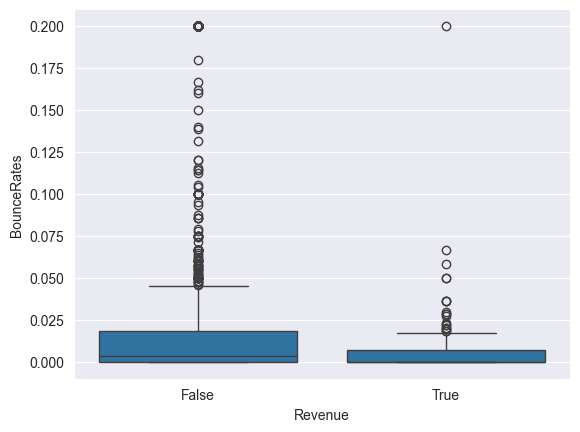

In [79]:
sns.boxplot(y = sample_df['BounceRates'], x = sample_df['Revenue'])

<Axes: xlabel='Revenue', ylabel='BounceRates'>

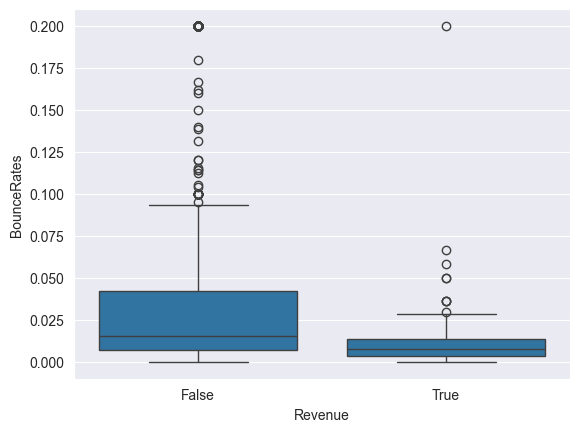

In [77]:
sns.boxplot(y = sample_df[sample_df['BounceRates'] != 0]['BounceRates'],x = sample_df['Revenue'])